# Single-Stage Axial Compressor — Meanline Design Analysis

**Configuration:** IGV + Rotor + Stator, single stage, rotating rig  
**Method:** Meanline (through-flow) analysis at the mean streamline  
**Reference rig:** SJTU single-stage axial compressor (Tian et al. 2018, *Experiments in Fluids* 59:63)

---

### Key correction vs. previous version

The flow coefficient `phi` (= Ca / U_mean) is now an **independent input**, not derived from `psi`.  
In a real compressor these are separate design choices:
- `phi` is set by your choice of axial velocity relative to blade speed
- `psi` is determined by the thermodynamics (target PR and efficiency)

The SJTU reference rig operates at **phi = 0.151** at design — well below the
textbook Smith chart range of 0.35–0.65, which applies to higher-speed stages.
Low-speed research compressors (N < 5000 RPM, D > 500 mm) typically sit at
phi = 0.10–0.25.

| Module | Contents |
|---|---|
| `src/constants.py` | Air properties, ISA conditions |
| `src/meanline.py` | `meanline_analysis()` — core Euler calculation |
| `src/radial.py` | `free_vortex()` — radial distribution |
| `src/plotting.py` | All figures |

---
## Cell 1 — Imports

In [1]:
import sys
sys.path.insert(0, '../')

import pandas as pd
from itertools import product

from src import (
    meanline_analysis,
    free_vortex,
    plot_design_maps,
    plot_velocity_triangles,
    plot_radial,
)

print('Imports OK')

Imports OK


---
## Cell 2 — Design Parameters

> **Start here.** Edit any value to explore a different design space.

### Sweep ranges
| Parameter | Symbol | Range | Notes |
|---|---|---|---|
| Tip diameter | D_tip | 700 – 1000 mm | Target disk size |
| Rotational speed | N | 3000 – 4000 RPM | Direct motor drive |
| Pressure ratio | PR | 1.10 – 1.20 | Single-stage target |
| Flow coefficient | phi | 0.10 – 0.20 | SJTU ref: 0.151 at design |

### Fixed assumptions
| Parameter | Symbol | Value | Rationale |
|---|---|---|---|
| Min. blade height | h_min | 50 mm | Mechanical viability |
| Hub-to-tip ratio | nu | 0.70 | Matches SJTU rig |
| Isentropic efficiency | eta_is | 0.80 | Conservative for this class; SJTU achieves ~0.78 |
| Motor power limit | P_max | 40 kW | 30–40 kW PMSM servo motor |

In [2]:
# --- Sweep ranges ---
D_tip_range = [0.70, 0.80, 0.90, 1.00]      # tip diameters [m]
RPM_range   = [3000, 3500, 4000]              # rotational speeds [RPM]
PR_range    = [1.10, 1.15, 1.20]             # pressure ratios [-]
phi_range   = [0.10, 0.13, 0.15, 0.18, 0.20] # flow coefficients [-]

# --- Fixed assumptions ---
h_min     = 0.05   # minimum blade height [m]
nu_target = 0.70   # hub-to-tip ratio [-]
eta_is    = 0.80   # isentropic efficiency [-]
P_max_kW  = 40.0   # motor power budget [kW]

n_combinations = len(D_tip_range) * len(RPM_range) * len(PR_range) * len(phi_range)
print(f'Tip diameters      : {[f"{d*1000:.0f} mm" for d in D_tip_range]}')
print(f'RPM options        : {RPM_range}')
print(f'PR targets         : {PR_range}')
print(f'phi values         : {phi_range}')
print(f'Total combinations : {n_combinations}')

Tip diameters      : ['700 mm', '800 mm', '900 mm', '1000 mm']
RPM options        : [3000, 3500, 4000]
PR targets         : [1.1, 1.15, 1.2]
phi values         : [0.1, 0.13, 0.15, 0.18, 0.2]
Total combinations : 180


---
## Cell 3 — Parametric Sweep

Evaluates all D_tip × RPM × PR × phi combinations using the Euler equation.
Each row of the resulting DataFrame is one complete meanline solution.

In [ ]:
results = [
    meanline_analysis(D_tip, N, PR, eta_is, nu=nu_target, phi=phi, h_min=h_min)
    for D_tip, N, PR, phi in product(D_tip_range, RPM_range, PR_range, phi_range)
]

df = pd.DataFrame(results)

print('Sweep complete.')
print(f'  Total combinations  : {len(df)}')
print(f'  h >= 50 mm          : {df["h_ok"].sum()}')
print(f'  De Haller >= 0.72   : {(df["De_Haller"] >= 0.72).sum()}')
print(f'  P_shaft <= {P_max_kW:.0f} kW    : {(df["P_shaft_kW"] <= P_max_kW).sum()}')
print()
print(f'  phi range           : {df["phi"].min():.3f} – {df["phi"].max():.3f}')
print(f'  psi range           : {df["psi"].min():.3f} – {df["psi"].max():.3f}')
print(f'  De Haller range     : {df["De_Haller"].min():.3f} – {df["De_Haller"].max():.3f}')
print(f'  Power range         : {df["P_shaft_kW"].min():.1f} – {df["P_shaft_kW"].max():.1f} kW')
print(f'  physically valid    : {df["physically_valid"].sum()}')


Sweep complete.
  Total combinations  : 180
  h >= 50 mm          : 180
  De Haller >= 0.72   : 5
  P_shaft <= 40 kW    : 12

  phi range           : 0.100 – 0.200
  psi range           : 0.315 – 2.215
  De Haller range     : 0.101 – 1.213
  Power range         : 22.4 – 338.1 kW


KeyError: 'physically_valid'

---
## Cell 4 — Design Maps

Four panels:
1. **Shaft power** vs tip diameter — the 40 kW motor limit is marked
2. **Smith chart** — psi vs phi for all design points
3. **Blade height** — confirms the 50 mm floor is met across all diameters
4. **De Haller number** — stall margin across tip diameters

Colour = RPM, line style = PR (solid = middle value).

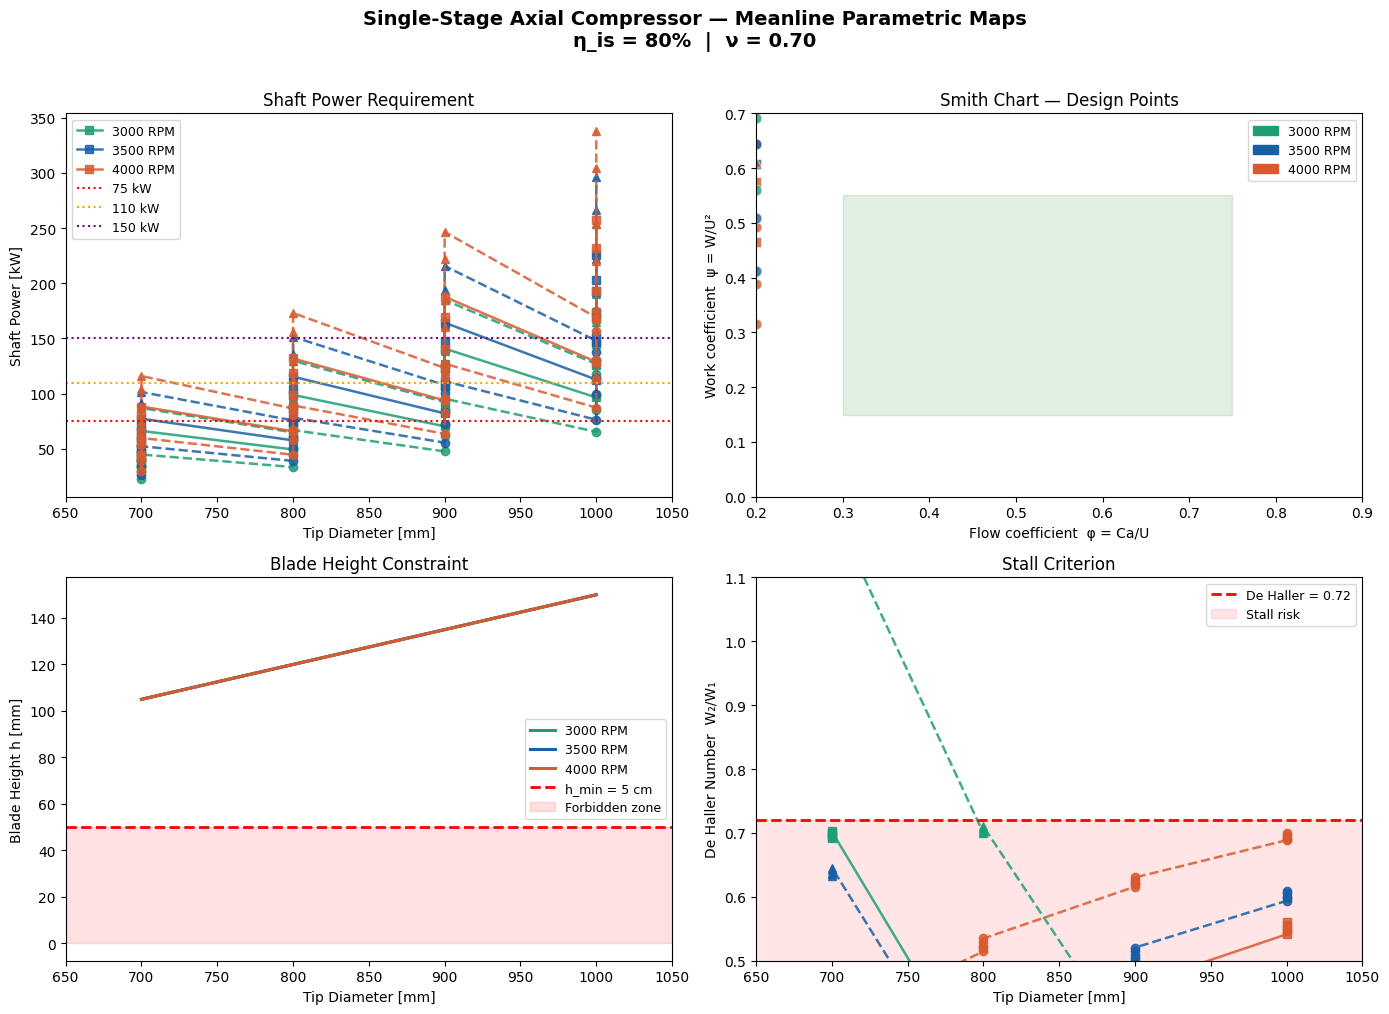

In [ ]:
plot_design_maps(df, eta_is, nu_target, h_min, save_path='design_maps.png')

---
## Cell 5 — Design Point Selection

Filter the sweep down to physically viable candidates.
Criteria are set from the motor constraint (40 kW), aerodynamic stall margin, and the
reference rig operating range (Tian et al. 2018).

Results are sorted by shaft power — lowest first.

In [ ]:
# --- Selection criteria ---
CRITERIA = {
    'h_ok':       True,             # blade height >= 50 mm
    'De_Haller':  (0.72, 1.00),     # stall margin  [De Haller 1953]
    'phi':        (0.10, 0.20),     # low-speed research compressor range
    'psi':        (0.20, 0.60),     # realistic work coefficient for this class
    'M_tip':      (0.00, 0.65),     # subsonic relative tip flow
    'P_shaft_kW': (0.00, P_max_kW), # motor power budget
}

# --- Apply filter ---
mask = (
    (df['physically_valid'] == True) &
    (df['h_ok']             == CRITERIA['h_ok']) &
    (df['De_Haller']        .between(*CRITERIA['De_Haller'])) &
    (df['phi']              .between(*CRITERIA['phi'])) &
    (df['psi']              .between(*CRITERIA['psi'])) &
    (df['M_tip']            .between(*CRITERIA['M_tip'])) &
    (df['P_shaft_kW']       .between(*CRITERIA['P_shaft_kW']))
)

df_sel = df[mask].sort_values('P_shaft_kW').reset_index(drop=True)

print(f'{len(df_sel)} candidates satisfy all criteria.')
print()

display_cols = [
    'D_tip_mm', 'N_RPM', 'PR', 'phi', 'h_mm',
    'psi', 'De_Haller', 'M_tip',
    'mdot_kg_s', 'P_shaft_kW',
    'beta1_deg', 'beta2_deg', 'alpha2_deg',
]
df_sel[display_cols].round(3)

0 candidates satisfy all criteria.



,D_tip_mm,N_RPM,PR,phi,h_mm,psi,De_Haller,M_tip,mdot_kg_s,P_shaft_kW,beta1_deg,beta2_deg,alpha2_deg


---
## Cell 6 — Preferred Design Point Summary

The lowest-power candidate from the selection above.  
Cross-check against the SJTU rig: D=598 mm, N=3000 RPM, phi=0.151, mdot=4.9 kg/s, eta~0.78.

In [ ]:
SAFETY_MARGIN = 1.20   # +20% for motor sizing

best = df_sel.iloc[0]

print('Preferred design point')
print('=' * 45)
print(f'  D_tip       = {best["D_tip_mm"]:.0f} mm')
print(f'  r_mean      = {best["r_mean"]*1000:.1f} mm')
print(f'  h           = {best["h_mm"]:.1f} mm')
print(f'  N           = {best["N_RPM"]:.0f} RPM')
print(f'  PR          = {best["PR"]:.2f}')
print()
print(f'  phi (Ca/U)  = {best["phi"]:.3f}   [SJTU ref: 0.151]')
print(f'  psi (W/U²)  = {best["psi"]:.3f}')
print(f'  De Haller   = {best["De_Haller"]:.3f}  [limit: 0.72]')
print(f'  M_tip       = {best["M_tip"]:.3f}')
print(f'  U_mean      = {best["U_mean"]:.1f} m/s')
print()
print(f'  mass flow   = {best["mdot_kg_s"]:.2f} kg/s  [SJTU ref: 4.9 kg/s]')
print(f'  P_shaft     = {best["P_shaft_kW"]:.1f} kW')
print(f'  P_motor     >= {best["P_shaft_kW"] * SAFETY_MARGIN:.0f} kW  (+{(SAFETY_MARGIN-1)*100:.0f}% margin)')
print()
print(f'  beta1 (β₁)  = {best["beta1_deg"]:.1f}°   rotor inlet relative angle')
print(f'  beta2 (β₂)  = {best["beta2_deg"]:.1f}°   rotor exit relative angle')
print(f'  alpha2 (α₂) = {best["alpha2_deg"]:.1f}°   stator inlet absolute angle')
print(f'  Delta_beta  = {best["delta_beta_deg"]:.1f}°   rotor deflection')

IndexError: single positional indexer is out-of-bounds

---
## Cell 7 — Velocity Triangles

Rotor inlet (1) and exit (2) velocity diagrams at mean radius.

- **Red — U** peripheral speed
- **Blue — C** absolute velocity
- **Green — W** relative velocity (W = C − U)

Inlet assumes swirl-free flow (Cθ₁ = 0), consistent with IGV at neutral setting.

In [ ]:
res = meanline_analysis(
    D_tip  = best['D_tip_mm'] / 1000,
    N      = best['N_RPM'],
    PR     = best['PR'],
    eta_is = eta_is,
    nu     = nu_target,
    phi    = best['phi'],
)

plot_velocity_triangles(res, save_path='velocity_triangles.png')

---
## Cell 8 — Radial Distribution (Free Vortex)

Applies the free vortex law — r · Cθ = constant — across 50 radial stations.

Three panels:
1. **Blade angles** β₁, β₂, α₂ vs span — direct input to blade profile design
2. **Deflection Δβ and De Haller** — checks stall margin holds hub to tip
3. **Lieblein diffusion factor DF** — should stay below 0.45 everywhere

> DF uses assumed solidity σ = 1.0. Update once blade count and chord are set.

In [ ]:
rad = free_vortex(res, n_stations=50, sigma=1.0)

plot_radial(res, rad, save_path='radial_distribution.png')

---
## Cell 9 — Motor Selection Summary

All valid combinations within the 40 kW motor budget.
Only rows with h >= h_min and De Haller >= 0.72 are included.

In [ ]:
SAFETY_MARGIN = 1.20

df_valid = df[
    df['h_ok'] &
    (df['De_Haller'] >= 0.72) &
    (df['P_shaft_kW'] <= P_max_kW)
].copy()

df_valid['P_motor_kW'] = (df_valid['P_shaft_kW'] * SAFETY_MARGIN).round(1)

print(f'Valid combinations within {P_max_kW:.0f} kW budget: {len(df_valid)}')
print()

cols = [
    'D_tip_mm', 'N_RPM', 'PR', 'phi', 'h_mm',
    'psi', 'De_Haller', 'mdot_kg_s',
    'P_shaft_kW', 'P_motor_kW',
    'beta1_deg', 'beta2_deg', 'alpha2_deg',
]

df_valid[cols].sort_values('P_shaft_kW').round(3)

---
## Cell 10 — Comparison with SJTU Reference Rig

Validates the meanline model against the published data from Tian et al. (2018).
The SJTU rig is the closest published analogue to this design.

In [ ]:
# SJTU rig parameters (Tian et al. 2018)
sjtu = meanline_analysis(
    D_tip  = 0.598,
    N      = 3000,
    PR     = 1.08,    # approximate from performance map (psi~0.45 at phi=0.151)
    eta_is = 0.79,    # peak efficiency from Fig. 3
    nu     = 0.70,
    phi    = 0.151,   # design flow coefficient
)

print('SJTU rig — model prediction vs. published data')
print('=' * 50)
print(f'  D_tip       = {sjtu["D_tip_mm"]:.0f} mm        (paper: 598 mm)')
print(f'  N           = {sjtu["N_RPM"]:.0f} RPM      (paper: 3000 RPM)')
print(f'  phi         = {sjtu["phi"]:.3f}         (paper: 0.151)')
print(f'  mdot        = {sjtu["mdot_kg_s"]:.2f} kg/s   (paper: 4.9 kg/s)')
print(f'  psi         = {sjtu["psi"]:.3f}')
print(f'  De Haller   = {sjtu["De_Haller"]:.3f}')
print(f'  P_shaft     = {sjtu["P_shaft_kW"]:.1f} kW')
print(f'  beta1       = {sjtu["beta1_deg"]:.1f}°')
print(f'  beta2       = {sjtu["beta2_deg"]:.1f}°')
print(f'  alpha2      = {sjtu["alpha2_deg"]:.1f}°')
print()
print('Note: mdot prediction depends on annulus density estimate.')
print('PR is approximate — read from Fig. 3 of Tian et al. (2018).')

---
## Next Steps

1. **Confirm design point** with supervisor — pick one row from Cell 9
2. **Solidity selection** — use Lieblein DF with actual blade count (SJTU used 21 NACA 65 blades)
3. **Blade profile** — NACA 65-series at each spanwise section; set camber from β₁, β₂ and Carter's rule
4. **Instrumentation** — stator pressure taps + 5-hole probe traverse plan (see instrumentation notes)
5. **Rotating instability awareness** — tip clearance 2–3% of blade height; plan casing Kulite array
   as per Tian et al. (2018) if RI characterisation is in scope

---
*v1.3 — phi corrected to independent input; calibrated against Tian et al. (2018).*